# Experimental data

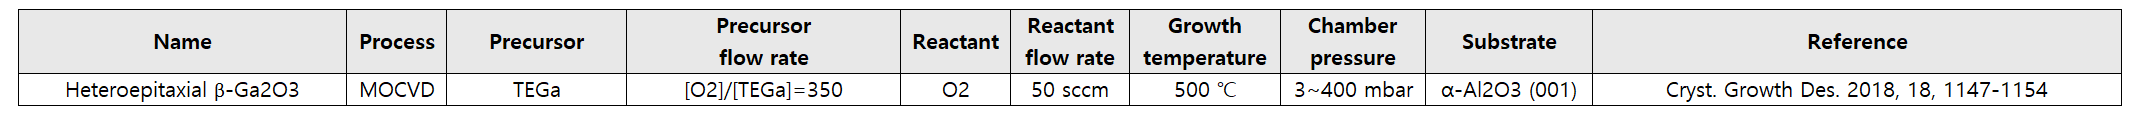

# 1. Calculating relative nucleation rates

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from matplotlib.patches import Wedge


In [2]:
# Physical constants
PI = math.pi
KB = 8.617e-2  # Boltzmann constant, unit: eV/K

def nucleation_rate(surface_meta, n_meta, surface_stable, n_stable, delta_g_rxn, bulk_diff, temp):
    """
    Calculate the nucleation rate
    
    Parameters:
    -----------
    surface_meta : float
        Surface energy of metastable phase (eV/Å²)
    n_meta : float
        Number of atoms per unit volume in metastable phase (atoms/Å³)
    surface_stable : float
        Surface energy of stable phase (eV/Å²)
    n_stable : float
        Number of atoms per unit volume in stable phase (atoms/Å³)
    delta_g_rxn : float
        Reaction free energy change (eV/atom)
    bulk_diff : float
        Bulk energy difference (eV/atom)
    temp : float
        Temperature (K)
    
    Returns:
    --------
    rate : float
        Calculated nucleation rate
    """
    try:
        # First term
        term1 = surface_meta**3 / (n_meta**2 * (delta_g_rxn + bulk_diff)**2)
        
        # Second term
        term2 = surface_stable**3 / (n_stable**2 * delta_g_rxn**2)
        
        # Constant coefficient in exponent
        constant = (16 * PI) / (3 * KB * temp)
        
        # Exponent
        exponent = constant * (term1 - term2)
        
        # Nucleation rate
        rate = np.exp(exponent)
        
        return rate
        
    except ZeroDivisionError:
        raise ValueError("Division by zero: n_meta, n_stable, delta_g_rxn, or temp cannot be zero.")
    except Exception as e:
        raise ValueError(f"Unexpected error occurred: {e}")

In [3]:
# Surfaced energy
b_surface = 48 # β-Ga2O3
b_surface_recon = 8 # Reconstruction energy of β-Ga2O3 (J. Mater. Chem. C, 2024, 12, 1820–1832)

e_surface = 71.76 # ε-Ga2O3
e_surface_recon = 27 #J. Mater. Chem. C, 2024, 12, 1820–1832


# Vibrational energy difference
vib_E_diff_e_b = 13

# Strain energy difference
strain_b_e_a_ga2o3 = -5.57 # on α-Ga2O3 substrate

# Interface energy
inter_b_a_Ga2O3 = 47 # Between β-Ga2O3 and α-Ga2O3 (J. Mater. Chem. C, 2025, 13, 1469–1476)
inter_e_a_Ga2O3 = 32 # Between ε-Ga2O3 and α-Ga2O3 (J. Mater. Chem. C, 2025, 13, 1469–1476)

# Density
density_b = 0.09092272200462186
density_b_a_ga2o3 = 0.09355506403533614
density_e = 0.09397063582356113
density_e_a_ga2o3 = 0.09482363798313029


C:\Users\NB\AppData\Local\Temp\ipykernel_4612\3951799056.py:45: RuntimeWarning: overflow encountered in exp
  rate = np.exp(exponent)
C:\Users\NB\AppData\Local\Temp\ipykernel_4612\3967641075.py:17: RuntimeWarning: divide by zero encountered in log
  lnJ_on = np.log(nucleation_rate(
C:\Users\NB\AppData\Local\Temp\ipykernel_4612\3967641075.py:47: RuntimeWarning: divide by zero encountered in log
  lnJ_wo = np.log(nucleation_rate(


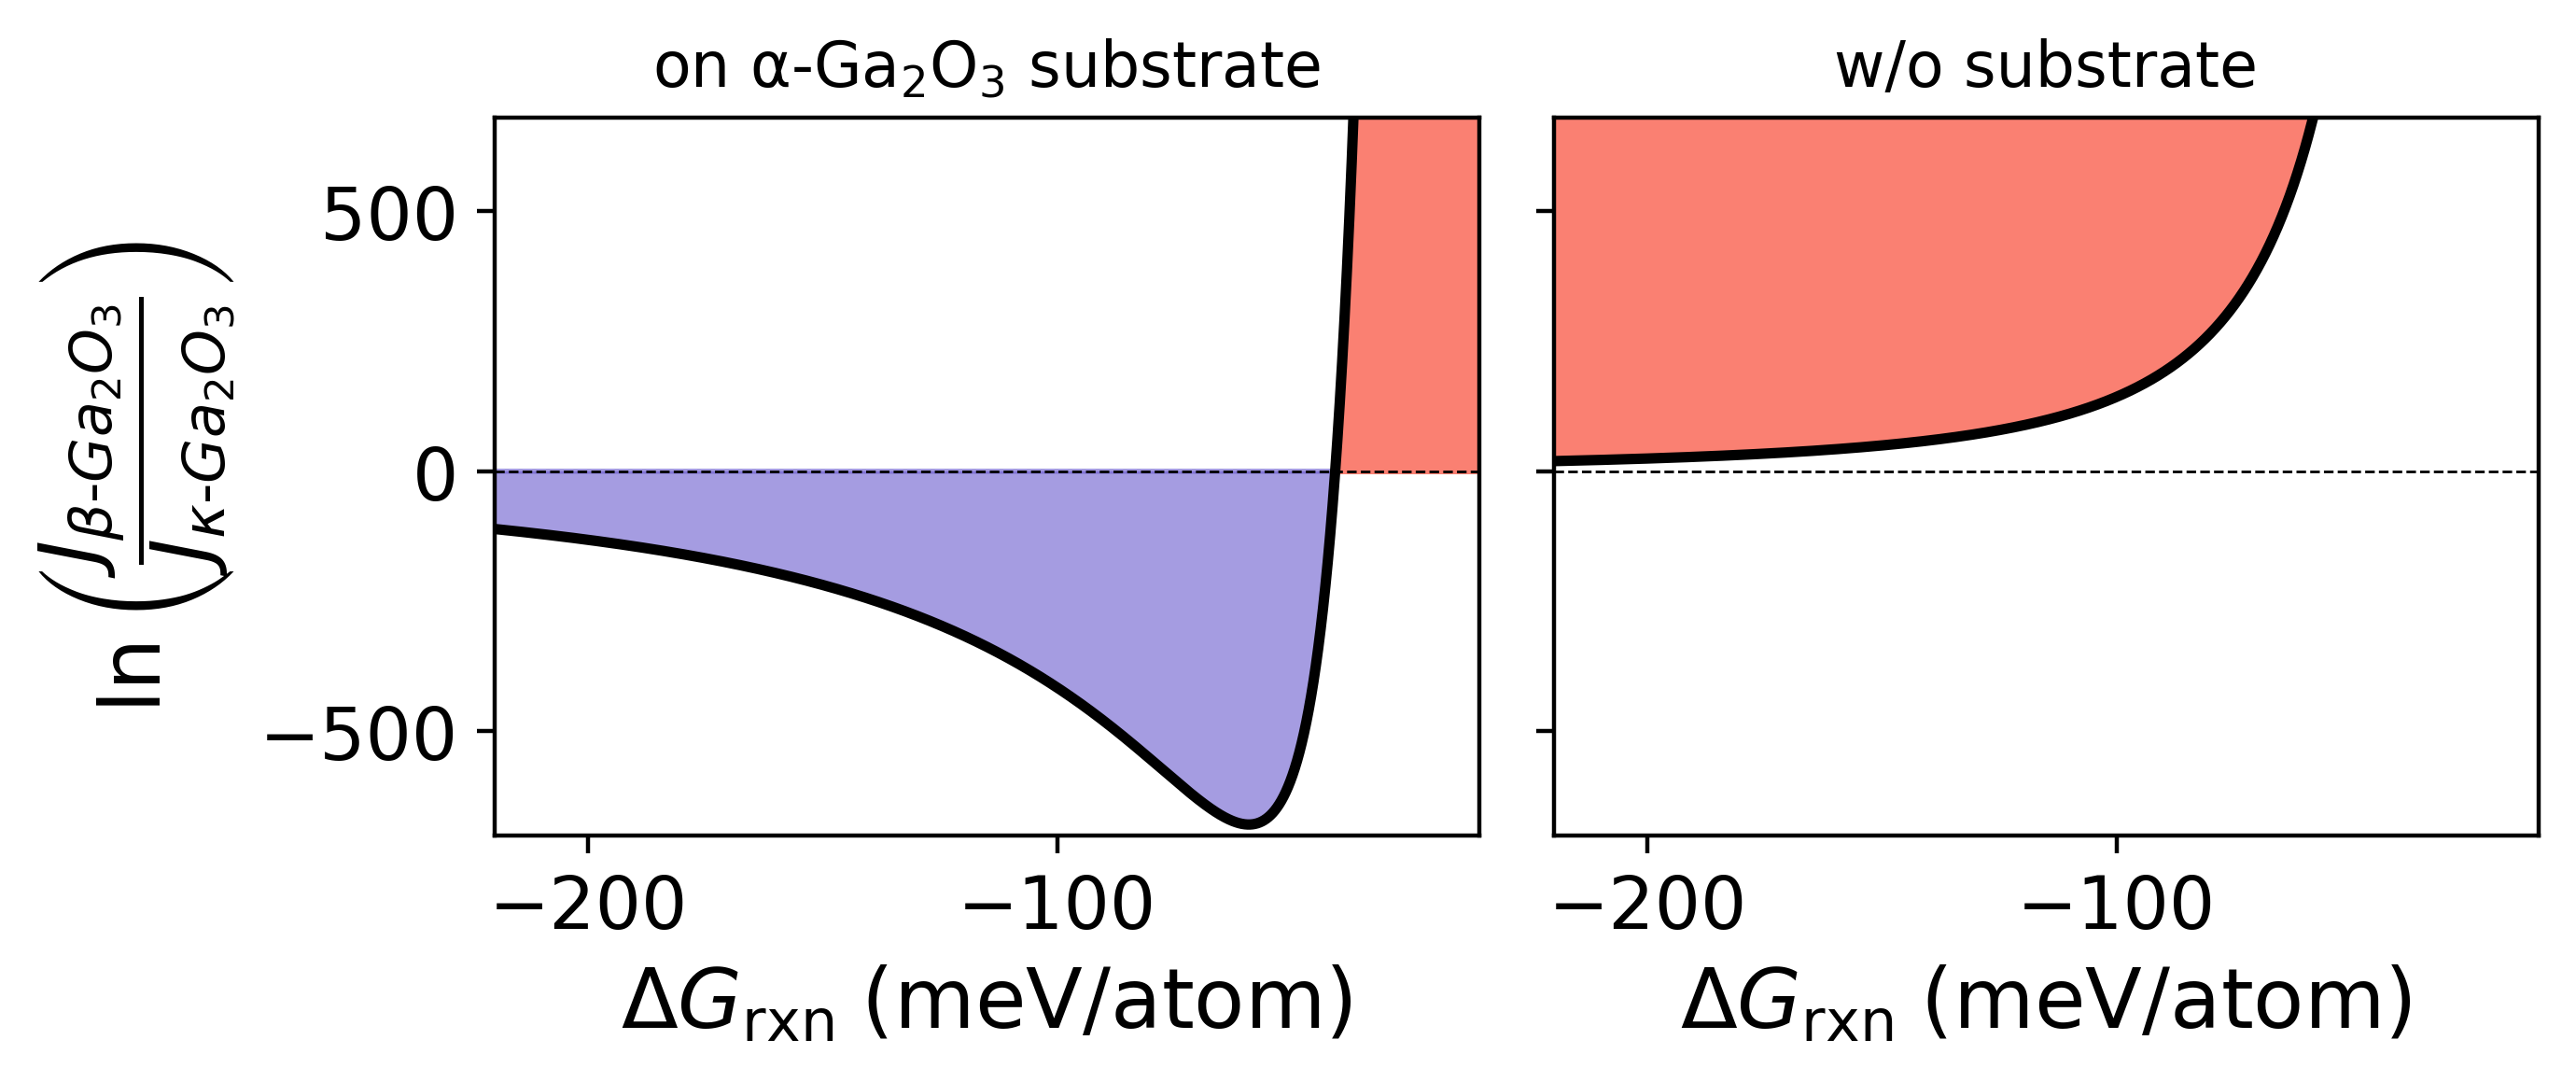

In [4]:
delta_g_rxn = np.arange(-300, 10, 0.01)
plt.figure(figsize=(7, 3), dpi=400)
T = 500 + 273  # K

ymin, ymax = -700, 680
xmin, xmax = -220, -10

lw = 2
ls = 12

# ===================== (1) on α-Ga2O3 =====================
ax1 = plt.subplot(1, 2, 1)
ax1.set_title("on α-Ga$_2$O$_3$ substrate")

ax1.axhline(0, color='k', linestyle='--', linewidth=0.5)

lnJ_on = np.log(nucleation_rate(
    e_surface + inter_e_a_Ga2O3 - e_surface_recon, density_e_a_ga2o3,
    b_surface + inter_b_a_Ga2O3 - b_surface_recon, density_b_a_ga2o3,
    delta_g_rxn,
    strain_b_e_a_ga2o3 + vib_E_diff_e_b,
    T
))

lnJ_on_clipped = np.clip(lnJ_on, ymin, ymax)

ax1.fill_between(delta_g_rxn, 0, lnJ_on_clipped, where=(lnJ_on_clipped < 0), 
                  color="slateblue", interpolate=True,alpha=0.6)

ax1.fill_between(delta_g_rxn, 0, lnJ_on_clipped, where=(lnJ_on_clipped >= 0), 
                  color="salmon", interpolate=True)

mask_finite = np.isfinite(lnJ_on)
ax1.plot(delta_g_rxn[mask_finite], lnJ_on[mask_finite], color="black", linewidth=lw)

ax1.set_ylabel(r"$\ln \left(\dfrac{J_{\beta\text{-}Ga_{2}O_{3}}}{J_{\kappa\text{-}Ga_{2}O_{3}}}\right)$", fontsize=ls+4)
ax1.set_xlabel(r"$\Delta G_{\mathrm{rxn}}\;(\mathrm{meV}/\mathrm{atom})$", fontsize=ls+4)
ax1.set_ylim(ymin, ymax)
ax1.set_xlim(xmin, xmax)
ax1.tick_params(labelsize=ls+2)

# ===================== (2) w/o substrate =====================
ax2 = plt.subplot(1, 2, 2)
ax2.axhline(0, color='k', linestyle='--', linewidth=0.5)
ax2.set_title("w/o substrate")

lnJ_wo = np.log(nucleation_rate(
    e_surface - e_surface_recon, density_e,
    b_surface - b_surface_recon, density_b,
    delta_g_rxn,
    vib_E_diff_e_b,
    T
))
ax2.plot(delta_g_rxn, lnJ_wo, linewidth=lw, color="black")

mask_positive_finite = (lnJ_wo >= 0) & np.isfinite(lnJ_wo)
lnJ_wo_for_fill = np.where(mask_positive_finite, lnJ_wo, 0)
ax2.fill_between(delta_g_rxn, lnJ_wo_for_fill, ymax, where=mask_positive_finite, 
                  color="salmon", interpolate=True)

ax2.set_xlabel(r"$\Delta G_{\mathrm{rxn}}\;(\mathrm{meV}/\mathrm{atom})$", fontsize=ls+4)
ax2.set_ylim(ymin, ymax)
ax2.set_xlim(xmin, xmax)
ax2.tick_params(labelsize=ls+2)
ax2.tick_params(axis='y', labelleft=False)

plt.tight_layout()

# 2. Reaction pathfindings 

In [5]:
import numpy as np
import collections


from pymatgen.entries.computed_entries import ComputedEntry
from rxn_network.entries.entry_set import GibbsEntrySet
from rxn_network.enumerators.basic import BasicEnumerator
from rxn_network.entries.interpolated import InterpolatedEntry
import pandas as pds


c:\Users\NB\anaconda3\envs\rxn3\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-09 21:32:49,455	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [6]:
# =============================================================================
# DFT-calculated Energies
# =============================================================================

# Precursors
TEGa = ComputedEntry("Ga(C2H5)3", -111.42420)
DEGa = ComputedEntry("Ga(C2H5)2", -73.72616)
MEGa = ComputedEntry("Ga(C2H5)", -37.59689)


# Reactants
O2 = ComputedEntry("O2", -9.8799) 

# Target
Ga2O3 = ComputedEntry("Ga2O3", -29.8385)  # beta phase

# By-products
C2H4 = ComputedEntry("C2H4", -31.980520)
CH3 = ComputedEntry("CH3", -18.16748)
C2H5 = ComputedEntry("C2H5", -34.86254)
CH4 = ComputedEntry("CH4", -18.83721)
CO2 = ComputedEntry("C2O4", -22.969825)
H2 = ComputedEntry("H2", -6.7903) 
H2O = ComputedEntry("H2O", -14.233623)

# Chemical potential of Ga
Ga = ComputedEntry("Ga8", -23.23820)

In [7]:
# =============================================================================
# Physical Constants
# =============================================================================
K_B = 1.380649e-23              # Boltzmann constant (J/K)
EV_PER_J = 1 / 1.60218e-19      # J to eV conversion
MOLAR_VOLUME_STP = 22414        # cm³/mol at STP


# =============================================================================
# Functions
# =============================================================================

def ideal_gas_entry(entry, T, P, P0=1.0):
    """
    Apply ideal gas correction: E_corrected = E + kT*ln(P/P0)
    
    Parameters:
    -----------
    entry : ComputedEntry
    T : float - Temperature (K)
    P : float - Pressure (atm)
    P0 : float - Reference pressure (atm), default=1.0
    
    Returns:
    --------
    ComputedEntry with corrected energy
    """
    kT_J = K_B * T
    correction_J = kT_J * np.log(P / P0)
    correction_eV = correction_J * EV_PER_J
    
    corrected_energy = entry.energy + correction_eV
    return ComputedEntry(entry.composition, corrected_energy)


def umol_per_min_to_sccm(flow_umol_min):
    """μmol/min -> SCCM"""
    return flow_umol_min * (MOLAR_VOLUME_STP / 1e6)




In [8]:
# Common parameters
P_CHAMBER = 60 / 760  # 60 Torr to atm

flow_O2 = 50.0     # sccm
flow_Ar = 50.0     # sccm
flow_N2 = 1000.0   # sccm (1 slm)
ratio_O2_TEGa = 390.0
flow_TEGa = flow_O2 / ratio_O2_TEGa 

P_tot_list = np.array([400, 200, 150, 100, 50, 35, 20, 10, 3])  # mbar
# print(P_tot_list)

flows = np.array([flow_O2, flow_Ar, flow_N2, flow_TEGa])
labels = ["O2", "Ar", "N2", "TEGa"]

fractions = flows / flows.sum()

# =========================
# Build DataFrame (no fractions shown)
# =========================
data = {
    "P_tot (mbar)": P_tot_list,
    "flow_O2 (sccm)": np.full_like(P_tot_list, flow_O2, dtype=float),
    "flow_Ar (sccm)": np.full_like(P_tot_list, flow_Ar, dtype=float),
    "flow_N2 (sccm)": np.full_like(P_tot_list, flow_N2, dtype=float),
    "flow_TEGa (sccm)": np.full_like(P_tot_list, flow_TEGa, dtype=float),
}

for lab, frac in zip(labels, fractions):
    data[f"P_{lab} (mbar)"] = frac * P_tot_list
mbar_to_atm = 1.0 / 1013.25


df = pds.DataFrame(data)

df["P_O2 (atm)"]   = df["P_O2 (mbar)"]   * mbar_to_atm
df["P_Ar (atm)"]   = df["P_Ar (mbar)"]   * mbar_to_atm
df["P_N2 (atm)"]   = df["P_N2 (mbar)"]   * mbar_to_atm
df["P_TEGa (atm)"] = df["P_TEGa (mbar)"] * mbar_to_atm


In [9]:
df

,P_tot (mbar),flow_O2 (sccm),flow_Ar (sccm),flow_N2 (sccm),flow_TEGa (sccm),P_O2 (mbar),P_Ar (mbar),P_N2 (mbar),P_TEGa (mbar),P_O2 (atm),P_Ar (atm),P_N2 (atm),P_TEGa (atm)
0,400,50.0,50.0,1000.0,0.128205,18.179699,18.179699,363.593987,0.046615,0.017942,0.017942,0.358839,4.600505e-05
1,200,50.0,50.0,1000.0,0.128205,9.089850,9.089850,181.796993,0.023307,0.008971,0.008971,0.179420,2.300252e-05
2,150,50.0,50.0,1000.0,0.128205,6.817387,6.817387,136.347745,0.017480,0.006728,0.006728,0.134565,1.725189e-05
3,100,50.0,50.0,1000.0,0.128205,4.544925,4.544925,90.898497,0.011654,0.004485,0.004485,0.089710,1.150126e-05
4,50,50.0,50.0,1000.0,0.128205,2.272462,2.272462,45.449248,0.005827,0.002243,0.002243,0.044855,5.750631e-06
5,35,50.0,50.0,1000.0,0.128205,1.590724,1.590724,31.814474,0.004079,0.001570,0.001570,0.031398,4.025442e-06
6,20,50.0,50.0,1000.0,0.128205,0.908985,0.908985,18.179699,0.002331,0.000897,0.000897,0.017942,2.300252e-06
7,10,50.0,50.0,1000.0,0.128205,0.454492,0.454492,9.089850,0.001165,0.000449,0.000449,0.008971,1.150126e-06
8,3,50.0,50.0,1000.0,0.128205,0.136348,0.136348,2.726955,0.000350,0.000135,0.000135,0.002691,3.450379e-07


In [10]:
all_rows = []

for idx, row in df.iterrows():   # df_pp: pressure table
    P_tot = row["P_tot (mbar)"]
    P_O2_atm = row["P_O2 (atm)"]
    P_TEGa_atm = row["P_TEGa (atm)"]

    # ===== ideal gas corrected energies =====
    
    TEGa_ideal = ideal_gas_entry(TEGa, T, P_TEGa_atm)
    DEGa_ideal = ideal_gas_entry(DEGa, T, P_TEGa_atm)
    MEGa_ideal = ideal_gas_entry(MEGa, T, P_TEGa_atm)
    O2_ideal   = ideal_gas_entry(O2,   T, P_O2_atm)
    entries = [TEGa_ideal,DEGa_ideal,MEGa_ideal,O2_ideal,Ga2O3, C2H4,CH3,C2H5,CH4,H2O,CO2,H2,Ga]
    entries_inter = []
    
    for entry in entries:
        entry_inter = InterpolatedEntry(entry.composition, entry.energy)
        entries_inter.append(entry_inter)
        
    gibbs_entries = GibbsEntrySet(entries=entries_inter)
    be = BasicEnumerator(n=3,precursors=[TEGa_ideal.composition,
                                         DEGa_ideal.composition,
                                         MEGa_ideal.composition,
                                         O2_ideal.composition],
                         targets=["Ga2O3"])
    rxns = be.enumerate(gibbs_entries)
    
    # ===== collect results =====
    for rxn in rxns:
        Grxn = round(rxn.energy_per_atom * 1000, 2)

        by_products = []
        for product in rxn.products:
            if product != Ga2O3.composition:
                by_products.append(product.reduced_formula)

        all_rows.append({
            "P_tot (mbar)": P_tot,
            "Precursor": "TEGa",
            "P_precursor (atm)": P_TEGa_atm,
            "Reactant": "O2",
            "P_reactant (atm)": P_O2_atm,
            "By-products": ', '.join(str(p) for p in by_products),
            "ΔG_rxn (meV/atom)": Grxn,
            "rxn": rxn
        })

2026-02-09 21:32:51,334 INFO rxn_network.utils.ray Ray is not initialized. Checking for existing cluster...
2026-02-09 21:32:51,334 INFO rxn_network.utils.ray Could not identify existing Ray instance. Creating a new one...


2026-02-09 21:32:53,153	INFO worker.py:2013 -- Started a local Ray instance.


2026-02-09 21:32:55,475 INFO rxn_network.utils.ray HOST: DESKTOP-9NR7JST, Num CPUs: 8.0, Total Memory: 4016322151.0


c:\Users\NB\anaconda3\envs\rxn3\lib\site-packages\ray\_private\worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
Enumerating reactions (BasicEnumerator): 100%|██████████| 8/8 [00:00<00:00, 33.87it/s]


In [11]:
# ===== final DataFrame =====
df_rxn = pds.DataFrame(
    all_rows,
    columns=["P_tot (mbar)", "Precursor","P_precursor (atm)", "Reactant", "By-products","P_reactant (atm)", "ΔG_rxn (meV/atom)", "rxn"]
)

df_rxn = df_rxn.sort_values(["P_tot (mbar)", "ΔG_rxn (meV/atom)"]).reset_index(drop=True)
df_rxn.insert(0, "Reaction", range(1, len(df_rxn) + 1))

df_rxn

,Reaction,P_tot (mbar),Precursor,P_precursor (atm),Reactant,By-products,P_reactant (atm),ΔG_rxn (meV/atom),rxn
0,1,3.0,TEGa,3.450379e-07,O2,"H2O, H2C",0.000135,-495.49,2 GaH5C2 + 2 O2 -> H2O + 4 H2C + Ga2O3
1,2,3.0,TEGa,3.450379e-07,O2,"H2, H2C",0.000135,-405.44,2 GaH5C2 + 1.5 O2 -> H2 + 4 H2C + Ga2O3
2,3,3.0,TEGa,3.450379e-07,O2,Ga(H5C2)3,0.000135,-399.23,3 GaH5C2 + 1.5 O2 -> Ga(H5C2)3 + Ga2O3
3,4,3.0,TEGa,3.450379e-07,O2,H5C2,0.000135,-351.42,GaH5C2 + 0.75 O2 -> H5C2 + 0.5 Ga2O3
4,5,3.0,TEGa,3.450379e-07,O2,"H2O, H2C",0.000135,-303.12,Ga(H5C2)2 + 1.25 O2 -> H2O + 4 H2C + 0.5 Ga2O3
...,...,...,...,...,...,...,...,...,...
265,266,400.0,TEGa,4.600505e-05,O2,"H2, CO2",0.017942,837.30,1.1 O2 + 0.4 GaH5C2 -> H2 + 0.2 Ga2O3 + 0.8 CO2
266,267,400.0,TEGa,4.600505e-05,O2,"H4C, CO2",0.017942,922.26,0.4 Ga(H5C2)2 + 0.9 O2 -> H4C + 0.2 Ga2O3 + 0....
267,268,400.0,TEGa,4.600505e-05,O2,"H4C, CO2",0.017942,1111.88,0.2667 Ga(H5C2)3 + 0.8 O2 -> H4C + 0.1333 Ga2O...
268,269,400.0,TEGa,4.600505e-05,O2,"H2, CO2",0.017942,1133.99,0.2 Ga(H5C2)2 + 0.95 O2 -> H2 + 0.1 Ga2O3 + 0....


In [12]:
# df_rxn.to_excel("test.xlsx")

In [13]:
# Filtering ΔG_rxn (meV/atom) range from -65 to -20 meV/atom
filtered_df = df_rxn[(df_rxn['ΔG_rxn (meV/atom)'] >= -80) & (df_rxn['ΔG_rxn (meV/atom)'] <= -30)]
filtered_df

,Reaction,P_tot (mbar),Precursor,P_precursor (atm),Reactant,By-products,P_reactant (atm),ΔG_rxn (meV/atom),rxn
12,13,3.0,TEGa,3.450379e-07,O2,"H3C, H2C",0.000135,-40.13,0.5 Ga(H5C2)2 + 0.375 O2 -> H3C + H2C + 0.25 G...
13,14,3.0,TEGa,3.450379e-07,O2,"H2, H2C",0.000135,-33.01,0.6667 Ga(H5C2)3 + 0.5 O2 -> H2 + 4 H2C + 0.33...
42,43,10.0,TEGa,1.150126e-06,O2,"H3C, H2C",0.000449,-48.64,0.375 O2 + 0.5 Ga(H5C2)2 -> H3C + 0.25 Ga2O3 +...
43,44,10.0,TEGa,1.150126e-06,O2,"H2, H2C",0.000449,-38.98,1.5 O2 + 2 Ga(H5C2)3 -> Ga2O3 + 3 H2 + 12 H2C
72,73,20.0,TEGa,2.300252e-06,O2,"H3C, H2C",0.000897,-53.54,0.375 O2 + 0.5 Ga(H5C2)2 -> H3C + H2C + 0.25 G...
73,74,20.0,TEGa,2.300252e-06,O2,"H2, H2C",0.000897,-42.42,0.5 O2 + 0.6667 Ga(H5C2)3 -> H2 + 4 H2C + 0.33...
102,103,35.0,TEGa,4.025442e-06,O2,"H2C, H3C",0.001570,-57.49,2 Ga(H5C2)2 + 1.5 O2 -> Ga2O3 + 4 H2C + 4 H3C
103,104,35.0,TEGa,4.025442e-06,O2,"H2C, H2",0.001570,-45.19,2 Ga(H5C2)3 + 1.5 O2 -> Ga2O3 + 12 H2C + 3 H2
132,133,50.0,TEGa,5.750631e-06,O2,"H2C, H3C",0.002243,-60.01,2 Ga(H5C2)2 + 1.5 O2 -> Ga2O3 + 4 H2C + 4 H3C
133,134,50.0,TEGa,5.750631e-06,O2,"H2, H2C",0.002243,-46.96,0.6667 Ga(H5C2)3 + 0.5 O2 -> H2 + 4 H2C + 0.33...


In [14]:
# filtered_df.to_excel("test2.xlsx")

In [15]:
# We screen "TEGa + O2 → Ga2O3 + H2 + CH2" reactions.
df_filtered2 = filtered_df[
    filtered_df["By-products"].isin(["H2, H2C", "H2C, H2"])
].reset_index(drop=True)

df_filtered2

,Reaction,P_tot (mbar),Precursor,P_precursor (atm),Reactant,By-products,P_reactant (atm),ΔG_rxn (meV/atom),rxn
0,14,3.0,TEGa,3.450379e-07,O2,"H2, H2C",0.000135,-33.01,0.6667 Ga(H5C2)3 + 0.5 O2 -> H2 + 4 H2C + 0.33...
1,44,10.0,TEGa,1.150126e-06,O2,"H2, H2C",0.000449,-38.98,1.5 O2 + 2 Ga(H5C2)3 -> Ga2O3 + 3 H2 + 12 H2C
2,74,20.0,TEGa,2.300252e-06,O2,"H2, H2C",0.000897,-42.42,0.5 O2 + 0.6667 Ga(H5C2)3 -> H2 + 4 H2C + 0.33...
3,104,35.0,TEGa,4.025442e-06,O2,"H2C, H2",0.001570,-45.19,2 Ga(H5C2)3 + 1.5 O2 -> Ga2O3 + 12 H2C + 3 H2
4,134,50.0,TEGa,5.750631e-06,O2,"H2, H2C",0.002243,-46.96,0.6667 Ga(H5C2)3 + 0.5 O2 -> H2 + 4 H2C + 0.33...
5,164,100.0,TEGa,1.150126e-05,O2,"H2C, H2",0.004485,-50.40,1.5 O2 + 2 Ga(H5C2)3 -> Ga2O3 + 12 H2C + 3 H2
6,194,150.0,TEGa,1.725189e-05,O2,"H2, H2C",0.006728,-52.41,0.6667 Ga(H5C2)3 + 0.5 O2 -> H2 + 4 H2C + 0.33...
7,224,200.0,TEGa,2.300252e-05,O2,"H2, H2C",0.008971,-53.84,0.5 O2 + 0.6667 Ga(H5C2)3 -> H2 + 4 H2C + 0.33...
8,254,400.0,TEGa,4.600505e-05,O2,"H2C, H2",0.017942,-57.28,1.5 O2 + 2 Ga(H5C2)3 -> Ga2O3 + 12 H2C + 3 H2


In [16]:
# From experimental, 
# Amorphous (3~10 mbar)
# epsilon (10~100mbar)
# beta (200~400 mbar)

In [17]:
rxns_list = df_filtered2["ΔG_rxn (meV/atom)"].tolist()
tot_list  = df_filtered2["P_tot (mbar)"].tolist()

ln_J_ratio_results = []
ymax = 650

for rxn, tot in zip(rxns_list, tot_list):

    ln_J_ratio = np.log(nucleation_rate(
        e_surface + inter_e_a_Ga2O3 - e_surface_recon, density_e_a_ga2o3, 
        b_surface + inter_b_a_Ga2O3 - b_surface_recon, density_b_a_ga2o3, 
        rxn,
        strain_b_e_a_ga2o3 + vib_E_diff_e_b, 
        T
    ))
    
    # inf / -inf 처리
    if not np.isfinite(ln_J_ratio):
        ln_J_ratio = ymax if ln_J_ratio > 0 else -ymax
        
    ln_J_ratio_results.append({
        "P_tot (mbar)": tot,
        "ΔG_rxn (meV/atom)": rxn,
        "ln_J_ratio": ln_J_ratio
    })
    
for result in ln_J_ratio_results:
    print(f"P_tot = {result['P_tot (mbar)']} mbar, "
          f"ΔG_rxn = {result['ΔG_rxn (meV/atom)']} meV/atom, "
          f"ln_J_ratio = {result['ln_J_ratio']:.4f}")

P_tot = 3.0 mbar, ΔG_rxn = -33.01 meV/atom, ln_J_ratio = 650.0000
P_tot = 10.0 mbar, ΔG_rxn = -38.98 meV/atom, ln_J_ratio = 255.9311
P_tot = 20.0 mbar, ΔG_rxn = -42.42 meV/atom, ln_J_ratio = -182.3974
P_tot = 35.0 mbar, ΔG_rxn = -45.19 meV/atom, ln_J_ratio = -393.2366
P_tot = 50.0 mbar, ΔG_rxn = -46.96 meV/atom, ln_J_ratio = -484.7028
P_tot = 100.0 mbar, ΔG_rxn = -50.4 meV/atom, ln_J_ratio = -597.7451
P_tot = 150.0 mbar, ΔG_rxn = -52.41 meV/atom, ln_J_ratio = -635.9938
P_tot = 200.0 mbar, ΔG_rxn = -53.84 meV/atom, ln_J_ratio = -654.3169
P_tot = 400.0 mbar, ΔG_rxn = -57.28 meV/atom, ln_J_ratio = -676.4641


C:\Users\NB\AppData\Local\Temp\ipykernel_4612\3951799056.py:45: RuntimeWarning: overflow encountered in exp
  rate = np.exp(exponent)


In [18]:
keep_P = {3.0, 20.0, 35.0, 50.0}

selected = [r for r in ln_J_ratio_results if r["P_tot (mbar)"] in keep_P]

for result in selected:
    print(f"P_tot = {result['P_tot (mbar)']} mbar, "
          f"ΔG_rxn = {result['ΔG_rxn (meV/atom)']} meV/atom, "
          f"ln_J_ratio = {result['ln_J_ratio']:.4f}")
    
delta_G_sel = [r["ΔG_rxn (meV/atom)"] for r in selected]
ln_J_sel    = [r["ln_J_ratio"] for r in selected]
P_tot_sel   = [r["P_tot (mbar)"] for r in selected]

P_tot = 3.0 mbar, ΔG_rxn = -33.01 meV/atom, ln_J_ratio = 650.0000
P_tot = 20.0 mbar, ΔG_rxn = -42.42 meV/atom, ln_J_ratio = -182.3974
P_tot = 35.0 mbar, ΔG_rxn = -45.19 meV/atom, ln_J_ratio = -393.2366
P_tot = 50.0 mbar, ΔG_rxn = -46.96 meV/atom, ln_J_ratio = -484.7028


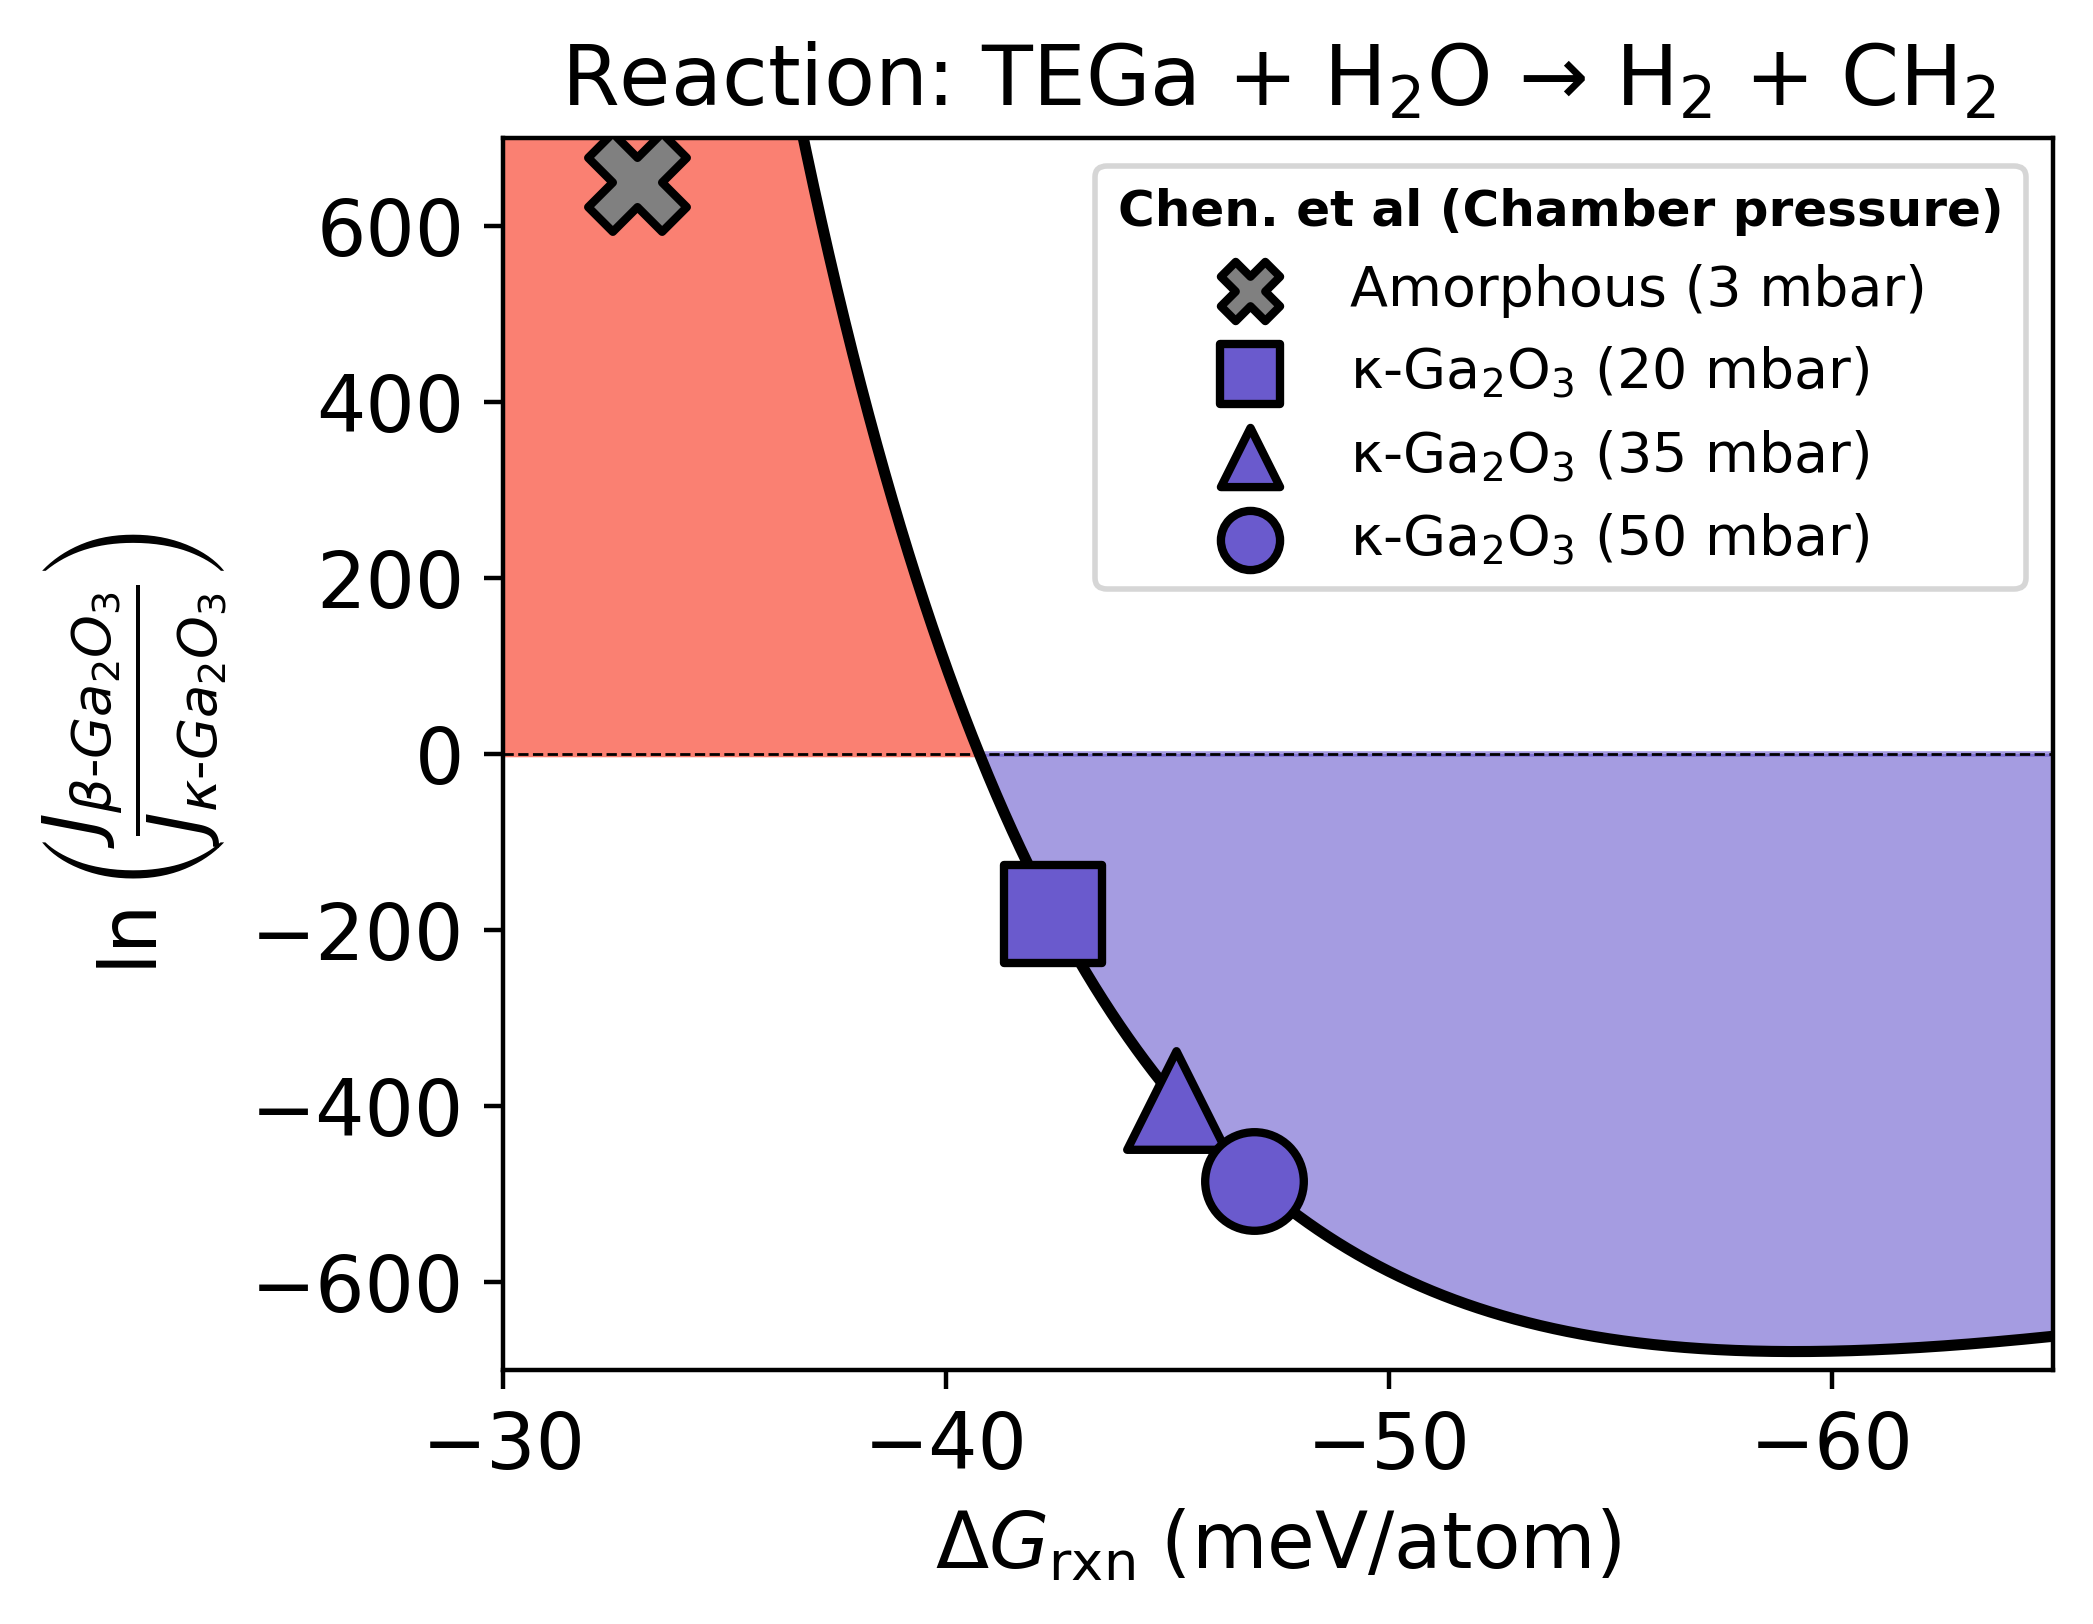

In [19]:
from matplotlib.colors import to_rgb

delta_g_rxn = np.arange(-300, 10, 0.01)

plt.figure(figsize=(5,4),dpi=400)

plt.axhline(0, color='k', linestyle='--', linewidth=0.5)
ymin, ymax = -700,700

plt.title("Reaction: TEGa + H$_2$O → H$_2$ + CH$_2$",fontsize=15)
s = 315
markers = ['X', 's', '^', 'o']   # 4 points
colors  = ['gray', 'slateblue', 'slateblue', 'slateblue']
phases = ["Amorphous", "κ-Ga$_2$O$_3$","κ-Ga$_2$O$_3$","κ-Ga$_2$O$_3$"]
labels = [f"{phase} ({int(P)} mbar)"
          for phase, P in zip(phases, P_tot_sel)]


for dG, lJ, mk, lab, col in zip(delta_G_sel, ln_J_sel, markers, labels, colors):
    plt.scatter(
        dG, lJ,
        s=s,
        edgecolors='k',
        linewidths=1.5,
        zorder=3,
        marker=mk,
        color=col,
        alpha=1,
        label=lab
    )

# plt.legend(
#     frameon=False,
#     fontsize=ls-2,
#     markerscale=0.55,
#     title="Chen et al (Chamber pressure)",
#     title_fontsize=ls
# )

leg = plt.legend(
    frameon=True,
    fontsize=ls-2,
    markerscale=0.6,
    title="Chen. et al (Chamber pressure)",
    title_fontsize=ls-3
)
leg.get_title().set_fontweight('bold')



lnJ_on_clipped = np.clip(lnJ_on, ymin, ymax)

plt.fill_between(delta_g_rxn, 0, lnJ_on_clipped, where=(lnJ_on_clipped < 0), 
                  color="slateblue", interpolate=True,alpha=0.6,zorder=1)

plt.fill_between(delta_g_rxn, 0, lnJ_on_clipped, where=(lnJ_on_clipped >=0), 
                  color="salmon", interpolate=True,zorder=1)

mask_finite = np.isfinite(lnJ_on)
plt.plot(delta_g_rxn[mask_finite], lnJ_on[mask_finite], color="black", linewidth=lw,zorder=2)

plt.ylabel(r"$\ln \left(\dfrac{J_{\beta\text{-}Ga_{2}O_{3}}}{J_{\kappa\text{-}Ga_{2}O_{3}}}\right)$", fontsize=ls+2)
plt.xlabel(r"$\Delta G_{\mathrm{rxn}}\;(\mathrm{meV}/\mathrm{atom})$", fontsize=ls+2)
plt.ylim(ymin,ymax)
plt.xlim(-30,-65)
plt.tick_params(labelsize=ls+2)

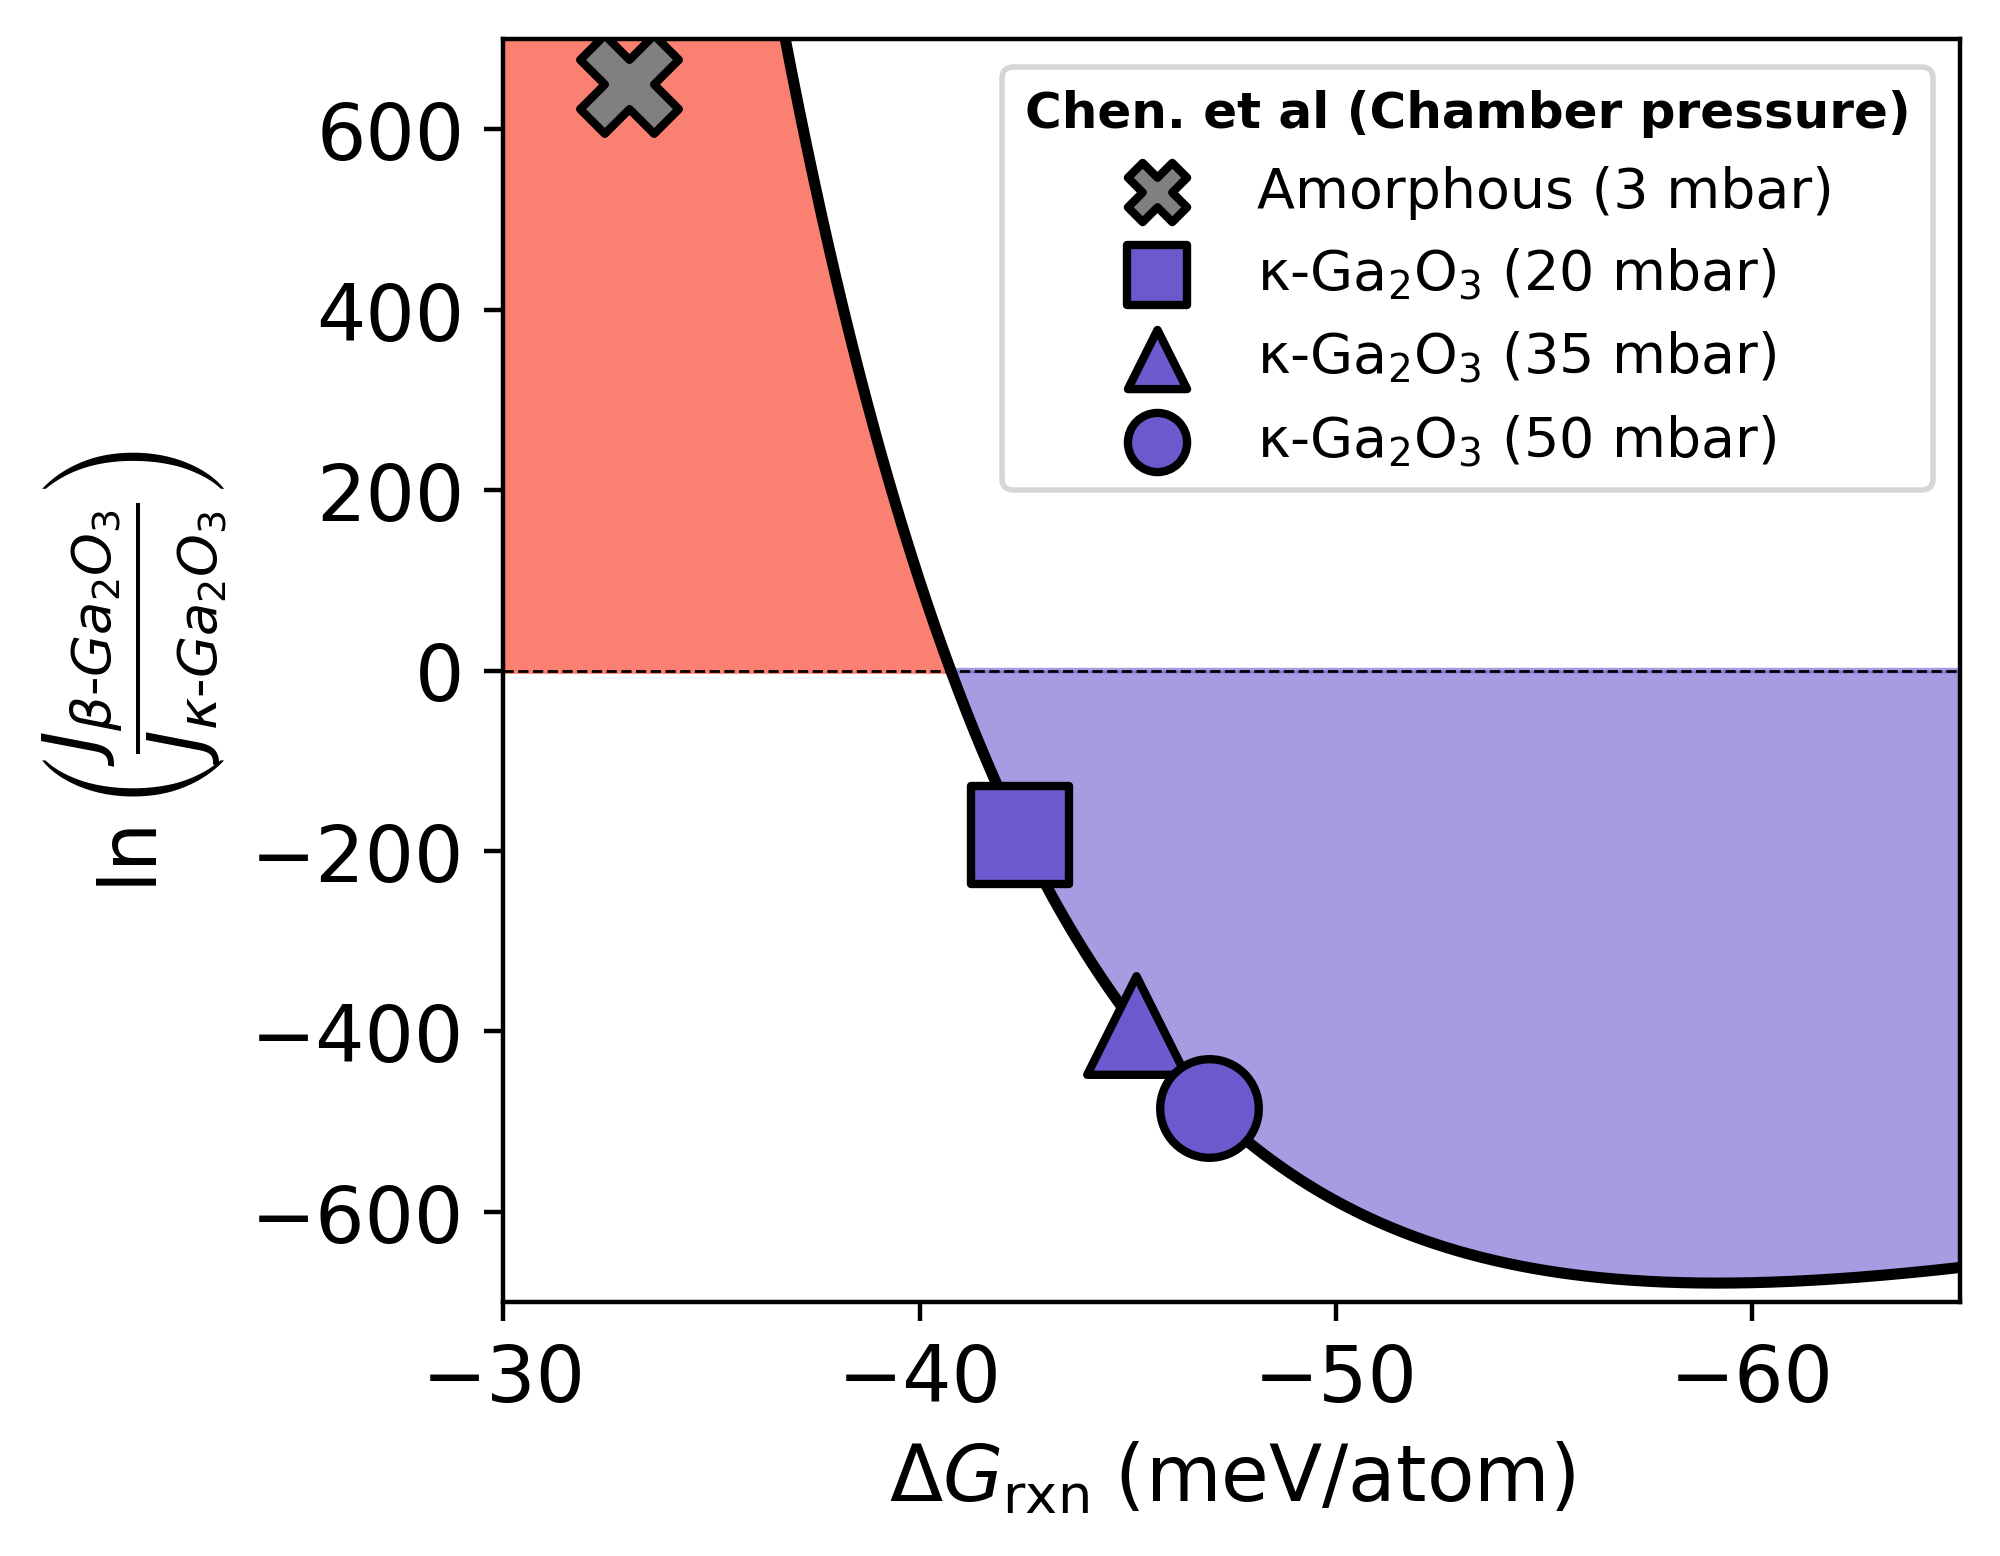

In [23]:
from matplotlib.colors import to_rgb

delta_g_rxn = np.arange(-300, 10, 0.01)

plt.figure(figsize=(4.7,4.1),dpi=400)

plt.axhline(0, color='k', linestyle='--', linewidth=0.5)
ymin, ymax = -700,700

# plt.title("Reaction: TEGa + H$_2$O → H$_2$ + CH$_2$",fontsize=15)
s = 315
markers = ['X', 's', '^', 'o']   # 4 points
colors  = ['gray', 'slateblue', 'slateblue', 'slateblue']
phases = ["Amorphous", "κ-Ga$_2$O$_3$","κ-Ga$_2$O$_3$","κ-Ga$_2$O$_3$"]
labels = [f"{phase} ({int(P)} mbar)"
          for phase, P in zip(phases, P_tot_sel)]


for dG, lJ, mk, lab, col in zip(delta_G_sel, ln_J_sel, markers, labels, colors):
    plt.scatter(
        dG, lJ,
        s=s,
        edgecolors='k',
        linewidths=1.5,
        zorder=3,
        marker=mk,
        color=col,
        alpha=1,
        label=lab
    )

# plt.legend(
#     frameon=False,
#     fontsize=ls-2,
#     markerscale=0.55,
#     title="Chen et al (Chamber pressure)",
#     title_fontsize=ls
# )

leg = plt.legend(
    frameon=True,
    fontsize=ls-2,
    markerscale=0.6,
    title="Chen. et al (Chamber pressure)",
    title_fontsize=ls-3
)
leg.get_title().set_fontweight('bold')



lnJ_on_clipped = np.clip(lnJ_on, ymin, ymax)

plt.fill_between(delta_g_rxn, 0, lnJ_on_clipped, where=(lnJ_on_clipped < 0), 
                  color="slateblue", interpolate=True,alpha=0.6,zorder=1)

plt.fill_between(delta_g_rxn, 0, lnJ_on_clipped, where=(lnJ_on_clipped >=0), 
                  color="salmon", interpolate=True,zorder=1)

mask_finite = np.isfinite(lnJ_on)
plt.plot(delta_g_rxn[mask_finite], lnJ_on[mask_finite], color="black", linewidth=lw,zorder=2)

plt.ylabel(r"$\ln \left(\dfrac{J_{\beta\text{-}Ga_{2}O_{3}}}{J_{\kappa\text{-}Ga_{2}O_{3}}}\right)$", fontsize=ls+2)
plt.xlabel(r"$\Delta G_{\mathrm{rxn}}\;(\mathrm{meV}/\mathrm{atom})$", fontsize=ls+2)
plt.ylim(ymin,ymax)
plt.xlim(-30,-65)
plt.tick_params(labelsize=ls+2)